In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import sqlite3
import numpy as np
import json
import os
import yaml

### Setup for matplotlib plot style

In [2]:
import os, matplotlib

print("MPLCONFIGDIR:", matplotlib.get_configdir())
print("cache dir:", matplotlib.get_cachedir())
print("user:", os.geteuid())

import matplotlib.font_manager as fm
sorted({f.name for f in fm.fontManager.ttflist if "cascadia" in f.name.lower()})

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Base seaborn theme (optional, but nice defaults)
sns.set_theme(style="white", context="notebook", font_scale=1.15)

mpl.rcParams.update({
    # --- Typography ---
    "font.family": "Cascadia Code",     # you installed this
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,

    # --- Figure layout ---
    "figure.figsize": (8, 5),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "figure.autolayout": False,         # prefer constrained_layout / tight_layout per-figure
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.08,

    # --- Axes look (modern = minimal spines) ---
    "axes.facecolor": "white",
    "axes.edgecolor": "0.25",
    "axes.linewidth": 1.0,
    "axes.spines.top": False,
    "axes.spines.right": False,

    # --- Grid (subtle) ---
    "axes.grid": True,
    "grid.color": "0.90",
    "grid.linewidth": 0.8,
    "grid.alpha": 1.0,
    "axes.axisbelow": True,             # grid behind artists

    # --- Ticks (clean + not too heavy) ---
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,

    # --- Lines/markers ---
    "lines.linewidth": 2.0,
    "lines.markersize": 5,

    # --- Legend ---
    "legend.frameon": False,

    # --- Images (for imshow) ---
    "image.interpolation": "nearest",   # for rasters / grids
})

import matplotlib as mpl

# mpl.rcParams["font.family"] = "sans-serif"
# mpl.rcParams["font.sans-serif"] = [
#     "Cascadia Code", "Cascadia Mono", "DejaVu Sans", "Liberation Sans"
# ]


MPLCONFIGDIR: /home/tut44474/.config/matplotlib
cache dir: /home/tut44474/.cache/matplotlib
user: 930200037


In [3]:
validation_path = Path("validation_5_one_pattern_10_bin_20_rep_v42_2")
new_validation_path = Path("validation_5_one_pattern_10_bin_20_rep_v42_3")
validation_input_path = validation_path / "input"
input_data = yaml.safe_load(Path(f"{validation_input_path}/input_validation.yml").read_text(encoding="utf-8"))
population_scale = input_data["artificial_rescaling_of_population_size"]
starting_date = input_data["starting_date"]
birth_Rate = input_data["birth_rate"]

# 1) Use the original dict
country_dict = {
    "country_code": "moz", 
    "country_name": "Mozambique",
    "population_scale": population_scale,
    "birth_rate": birth_Rate,
    }
country_json = json.dumps(country_dict, ensure_ascii=False)
# 3) Attribute-style access (SimpleNamespace)
from types import SimpleNamespace
country = json.loads(country_json, object_hook=lambda d: SimpleNamespace(**d))
print(country.country_code)

data_path = Path("data")
exp_path = validation_path
output_path = Path(exp_path) / "output"
analysis_path = Path(exp_path) / "analysis"
os.makedirs(analysis_path, exist_ok=True)

print(data_path)
print(output_path)
print(analysis_path)

moz
data
validation_5_one_pattern_10_bin_20_rep_v42_2/output
validation_5_one_pattern_10_bin_20_rep_v42_2/analysis


In [4]:
def read_raster(file: Path | str, nodata: int = -9999) -> tuple[np.ndarray, dict]:
    file_path = Path(file)
    if not file_path.is_file():
        raise FileNotFoundError(f"Raster file not found: {file}")

    with open(file_path, "r") as f:
        lines = f.read().splitlines()

    header = lines[:6]
    body = lines[6:]

    meta_raw = {}
    for line in header:
        k, v = line.split()
        meta_raw[k.lower()] = v

    metadata = {
        "ncols": int(float(meta_raw["ncols"])),
        "nrows": int(float(meta_raw["nrows"])),
        "xllcorner": float(meta_raw["xllcorner"]),
        "yllcorner": float(meta_raw["yllcorner"]),
        "cellsize": float(meta_raw["cellsize"]),
        "NODATA_value": int(float(meta_raw.get("nodata_value", nodata))),
    }
    nd = metadata["NODATA_value"]

    nrows, ncols = metadata["nrows"], metadata["ncols"]
    raster = np.zeros((nrows, ncols), dtype=float)

    for i, line in enumerate(body):
        vals = np.fromstring(line, sep=" ", dtype=float)
        if vals.size != ncols:
            raise ValueError(f"Row {i} has {vals.size} cols; expected {ncols}")
        raster[i, :] = vals

    # DO NOT convert nodata to NaN
    # raster[raster == nd] = np.nan

    return raster, metadata

def write_raster(
    raster: np.ndarray,
    file: Path | str,
    xllcorner: float,
    yllcorner: float,
    cellsize: int = 5000,
    mask_raster: np.ndarray | None = None,
    nodata: int = -9999,
) -> None:
    file_path = Path(file)
    if not file_path.parent.exists():
        raise FileNotFoundError(f"Directory does not exist: {file_path.parent}")

    nrows, ncols = raster.shape
    nd = float(nodata)

    raster_out = raster.astype(float, copy=True)

    # Treat non-finite as nodata (just in case)
    raster_out[~np.isfinite(raster_out)] = nd

    if mask_raster is not None:
        if mask_raster.shape != raster_out.shape:
            raise ValueError(
                f"mask_raster shape {mask_raster.shape} does not match raster shape {raster_out.shape}"
            )
        mask = mask_raster.astype(float, copy=False)
        mask_nodata = (mask == nd) | ~np.isfinite(mask)
        raster_out[mask_nodata] = nd

    with open(file_path, "w") as f:
        f.write(f"ncols\t{ncols}\n")
        f.write(f"nrows\t{nrows}\n")
        f.write(f"xllcorner\t{xllcorner}\n")
        f.write(f"yllcorner\t{yllcorner}\n")
        f.write(f"cellsize\t{cellsize}\n")
        f.write(f"NODATA_value\t{nodata}\n")

        for row in raster_out:
            line = [str(nodata) if v == nd else f"{v:.5f}" for v in row]
            f.write(" ".join(line) + "\n")

In [5]:
# agg_pfpr_pixel_df = pd.read_csv(analysis_path / "agg_prevalence_2_to_10_pixel.csv")
# agg_pfpr_pixel_df.head(1000).to_csv(analysis_path / "agg_prevalence_2_to_10_pixel_head1000.csv", index=False)
# agg_pfpr_pixel_df.tail(1000).to_csv(analysis_path / "agg_prevalence_2_to_10_pixel_tail1000.csv", index=False)
# print(agg_pfpr_pixel_df.location_id.unique())

findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.


[ok] 31821/32011 locations present; 190 cells have no sim row and will keep their current beta.
[info] obs/sim on 31483 scaled cells | p50=0.97 p90=1.05 p95=1.18 p99=1.62
[info] MAX_BETA_FACTOR=2 clamps 0.7% of scaled cells
[info] sim≈0 & obs>0 cells filled : 0 (beta in [0.0004, 2.5094])
[info] obs==0 cells set to beta=0 : 338
[info] method='ratio' GAIN=1.0 | max |Δbeta|=2.2743
[info] cells hitting BETA_MAX=10.0: 0

Adjusted beta raster saved to: validation_5_one_pattern_10_bin_20_rep_v42_2/analysis/moz_beta_adjusted_using_pfpr2to10.asc


findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font famil

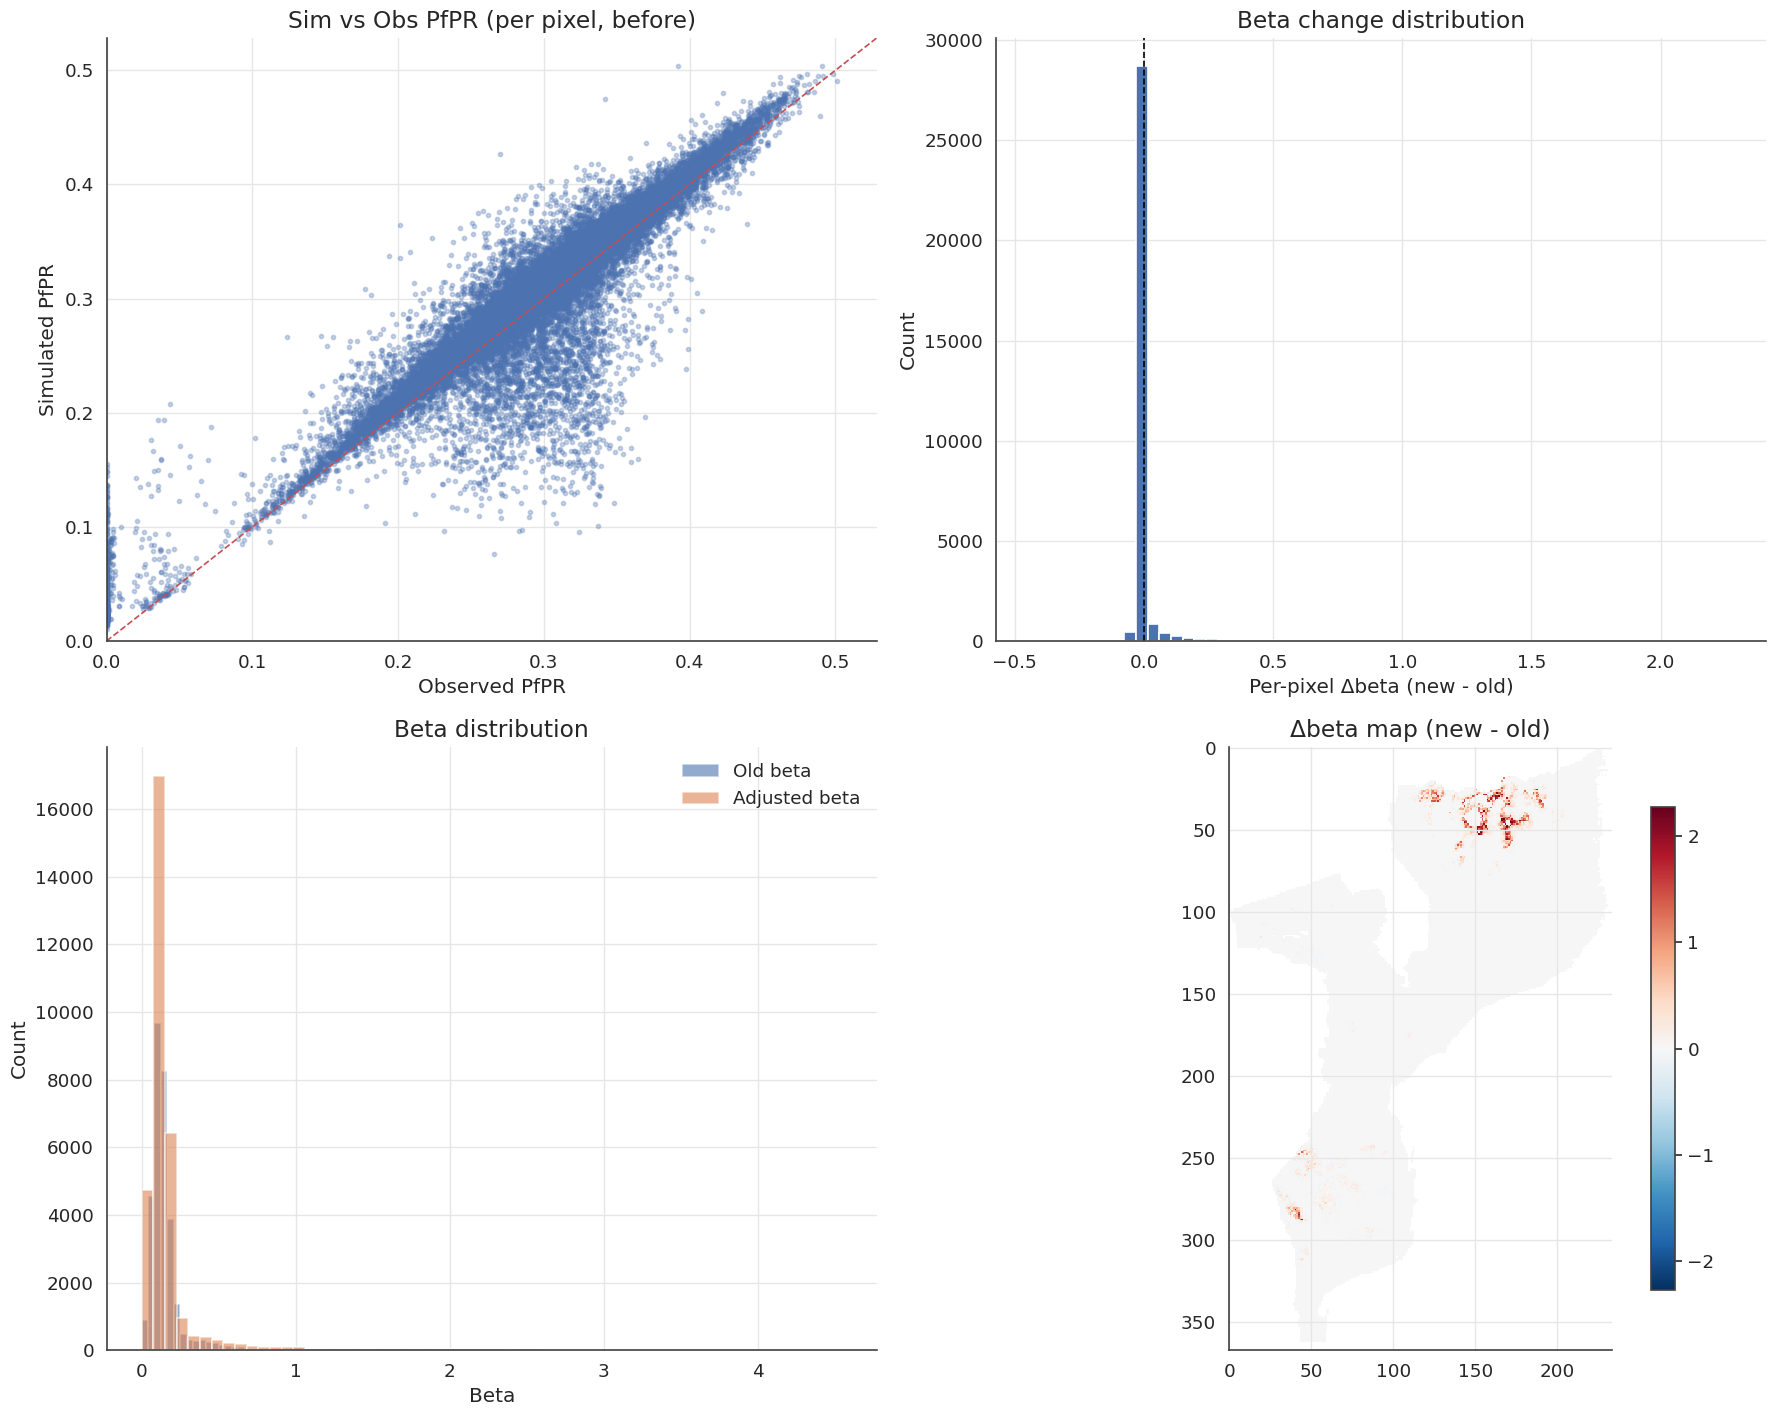


SUMMARY
method / GAIN              : ratio / 1.0
cells adjusted             : 31821
cells left unchanged (holes): 190
mean |obs-sim| PfPR (before): 0.0190
mean Δbeta                 : +0.0193
max |Δbeta|                : 2.2743
cells hitting BETA_MAX     : 0


In [6]:
# =============================================================================
# Adjust beta PIXEL-WISE so simulated PfPR(2-10) moves toward observed PfPR.
#
#   sim  : agg_prevalence_2_to_10_pixel.csv   (one row per location_id, 20 reps)
#   obs  : moz_pfpr.asc                        (observed PfPR raster)
#   beta : moz_beta.asc                        (current beta raster)
#
# location_id in the sim CSV runs 0..N-1 and is assigned in row-major scan order
# over the NON-NODATA cells of the raster. We verify that count + ordering BEFORE
# touching beta, then apply a per-pixel correction.
#
# Uses read_raster / write_raster helpers.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ── 0. Paths ─────────────────────────────────────────────────────────────────
beta_path     = f"{validation_input_path}/moz_beta.asc"
pfpr_obs_path = f"{data_path}/moz_pfpr2to10.asc"                       # observed PfPR raster
pfpr_sim_csv  = f"{analysis_path}/agg_prevalence_2_to_10_pixel.csv"

new_beta_output_path = f"{analysis_path}/moz_beta_adjusted_using_pfpr2to10.asc"

# ── 1. Config ────────────────────────────────────────────────────────────────
# Put sim and obs on a COMMON scale. Sim cols are 0-100 (percent).
# Set PFPR_OBS_SCALE = 100.0 if the obs raster is also 0-100, or 1.0 if it is a
# proportion in [0, 1] (MAP-style rasters usually are).
PFPR_SIM_SCALE = 100.0
PFPR_OBS_SCALE = 1.0

# Which monthly_data_id to calibrate against. None = average over all rows per
# location. Otherwise pass the specific id (e.g. the target month).
MONTHLY_DATA_ID = None

# Adjustment method (how a per-pixel PfPR gap maps to a beta change):
#   "ratio"     : beta *= (obs / sim) ** DAMPING    -> scale beta by the PfPR ratio
#   "delta"     : beta += GAIN * (obs - sim)        -> additive, proportional to the change
#   "rel_delta" : beta *= (1 + GAIN * (obs - sim))
METHOD   = "ratio"
DAMPING        = 1.0     # exponent on obs/sim. 1.0 = pure ratio; <1.0 = compress extremes
MAX_BETA_FACTOR = 2.0    # clamp the multiplier to [1/F, F] (guards sim≈0 -> inf)
MIN_SIM_PFPR   = 1e-3    # floor so the ratio is finite where sim≈0

GAIN     = 1.0     # (delta methods only) beta change per unit PfPR gap
BETA_MAX = 10.0    # final absolute safety cap on beta (set low to bound harder)

# Edge cases for the "ratio" method (scaling breaks when sim≈0, since beta*~0≈0):
#   sim≈0 & obs>0 : can't scale up from ~0 -> assign beta DIRECTLY from obs,
#                   mapped linearly into [BETA_FILL_MIN, BETA_FILL_MAX].
#   obs==0        : set beta = 0 (target = no transmission), bypassing the clamp.
# "sim≈0" means sim <= MIN_SIM_PFPR (set MIN_SIM_PFPR = 0 to require literal zero).
BETA_FILL_MIN = None   # None -> smallest positive beta in the raster
BETA_FILL_MAX = None   # None -> largest beta in the raster

# ── 2. Load rasters ──────────────────────────────────────────────────────────
beta,     beta_meta = read_raster(beta_path)
pfpr_obs, obs_meta  = read_raster(pfpr_obs_path)

NODATA = beta_meta["NODATA_value"]

if beta.shape != pfpr_obs.shape:
    raise ValueError(
        f"Raster shapes differ: beta={beta.shape}, pfpr_obs={pfpr_obs.shape}"
    )

# ── 3. Build the location footprint and VALIDATE against the sim CSV ──────────
# The canonical footprint is the set of cells MaSim assigned location_ids to.
# Here we derive it from the obs raster; we also confirm beta agrees so we don't
# silently scale a cell that has no location (or vice-versa).
obs_valid  = (pfpr_obs != NODATA)
beta_valid = (beta     != NODATA)

if not np.array_equal(obs_valid, beta_valid):
    n_only_obs  = int((obs_valid & ~beta_valid).sum())
    n_only_beta = int((beta_valid & ~obs_valid).sum())
    raise ValueError(
        "NODATA footprints of obs and beta rasters differ "
        f"(obs-only cells={n_only_obs}, beta-only cells={n_only_beta}). "
        "location_id mapping is only well-defined on a shared footprint."
    )

# Row-major (C-order) flat indices of the valid cells == location ordering.
flat_valid_idx = np.flatnonzero(obs_valid.ravel(order="C"))
n_valid = flat_valid_idx.size

# ── 4. Sim CSV → per-location PfPR (chunked; safe for the full ~1.2GB file) ───
# Per row: mean over the pfpr_2to10_* columns. Per location: mean over its rows.
# Streamed so we never hold the whole file in memory.
head = pd.read_csv(pfpr_sim_csv, nrows=0)
pf_cols = [c for c in head.columns if c.startswith("pfpr_2to10_")]
if not pf_cols:
    raise ValueError("No pfpr_2to10_* columns found in sim CSV")

use_cols = ["location_id"] + pf_cols
if "monthly_data_id" in head.columns:
    use_cols = ["monthly_data_id"] + use_cols

sum_s = pd.Series(dtype="float64")   # running sum  of per-row PfPR, by location
cnt_s = pd.Series(dtype="float64")   # running count of rows,        by location

reader = pd.read_csv(
    pfpr_sim_csv, usecols=use_cols,
    dtype={c: "float32" for c in pf_cols}, chunksize=1_000_000,
)
for chunk in reader:
    if MONTHLY_DATA_ID is not None and "monthly_data_id" in chunk.columns:
        chunk = chunk[chunk["monthly_data_id"] == MONTHLY_DATA_ID]
        if chunk.empty:
            continue
    chunk = chunk.assign(_pfpr=chunk[pf_cols].mean(axis=1))
    g = chunk.groupby("location_id")["_pfpr"].agg(["sum", "count"])
    sum_s = sum_s.add(g["sum"],   fill_value=0.0)
    cnt_s = cnt_s.add(g["count"], fill_value=0.0)

if cnt_s.empty:
    raise ValueError("No rows aggregated (check MONTHLY_DATA_ID filter)")

sim_pfpr = (sum_s / cnt_s).sort_index()

# ---- the matching check the pipeline needs BEFORE adjusting anything ----------
sim_locs = sim_pfpr.index.values
# location_id is the GLOBAL row-major index into the 0..n_valid-1 footprint.
# The sim CSV may legitimately be MISSING some locations (cells with no PfPR-
# eligible individuals in the window). Those cells are left unchanged, not an
# error. We only reject things that would break the mapping itself.
if sim_locs.min() < 0 or sim_locs.max() >= n_valid:
    raise ValueError(
        f"location_id out of range: got [{sim_locs.min()}, {sim_locs.max()}], "
        f"raster footprint is 0..{n_valid - 1}. Mapping is invalid."
    )
if pd.Index(sim_locs).has_duplicates:
    raise ValueError("Duplicate location_id after aggregation; cannot map.")

n_missing = n_valid - sim_locs.size
if sim_locs.max() != n_valid - 1:
    # last cell absent is allowed, but if the max is far below n_valid it may
    # mean the ids were re-indexed densely (different convention) -> warn loudly.
    print(f"[warn] max location_id={sim_locs.max()} < {n_valid - 1}; "
          f"verify ids are global raster indices, not a dense 0..M re-indexing.")
print(f"[ok] {sim_locs.size}/{n_valid} locations present; "
      f"{n_missing} cells have no sim row and will keep their current beta.")

# Align sim onto the full location grid; NaN marks the holes.
sim_vec = sim_pfpr.reindex(np.arange(n_valid)).to_numpy() / PFPR_SIM_SCALE
obs_vec = pfpr_obs.ravel(order="C")[flat_valid_idx] / PFPR_OBS_SCALE
have_sim = np.isfinite(sim_vec)                       # cells we can adjust

# ── 5. Per-pixel adjusted beta ───────────────────────────────────────────────
beta_old_vec = beta.ravel(order="C")[flat_valid_idx].astype(float).copy()
beta_new_vec = beta_old_vec.copy()        # holes (no sim) stay unchanged

o = obs_vec[have_sim]
s = sim_vec[have_sim]
b = beta_old_vec[have_sim]
gap = o - s                                # signed PfPR change we want, 0-1 scale

if METHOD == "delta":
    b_new = b + GAIN * gap
elif METHOD == "rel_delta":
    b_new = b * (1.0 + GAIN * gap)
elif METHOD == "ratio":
    s_safe = np.maximum(s, MIN_SIM_PFPR)
    f = np.clip((o / s_safe) ** DAMPING, 1.0 / MAX_BETA_FACTOR, MAX_BETA_FACTOR)
    b_new = b * f

    # report the obs/sim distribution on normally-scaled cells (sim>floor, obs>0)
    scaled = (s > MIN_SIM_PFPR) & (o > 0.0)
    if scaled.any():
        rr = o[scaled] / s[scaled]
        p50, p90, p95, p99 = np.percentile(rr, [50, 90, 95, 99])
        cl = np.mean((rr > MAX_BETA_FACTOR) | (rr < 1.0 / MAX_BETA_FACTOR)) * 100
        print(f"[info] obs/sim on {int(scaled.sum())} scaled cells | "
              f"p50={p50:.2f} p90={p90:.2f} p95={p95:.2f} p99={p99:.2f}")
        print(f"[info] MAX_BETA_FACTOR={MAX_BETA_FACTOR:g} clamps {cl:.1f}% of scaled cells")

    # resolve the fill range from the beta raster if not set explicitly
    _bpos = beta_old_vec[beta_old_vec > 0]
    fill_min = BETA_FILL_MIN if BETA_FILL_MIN is not None else (
        float(_bpos.min()) if _bpos.size else 0.0)
    fill_max = BETA_FILL_MAX if BETA_FILL_MAX is not None else float(beta_old_vec.max())
    obs_ref  = float(np.nanmax(obs_vec)) or 1.0

    # sim≈0 & obs>0 : assign beta from obs (proportional within the fill range)
    dead_sim = (s <= MIN_SIM_PFPR) & (o > 0.0)
    frac = np.clip(o[dead_sim] / obs_ref, 0.0, 1.0)
    b_new[dead_sim] = fill_min + (fill_max - fill_min) * frac

    # obs==0 : force beta to 0 (overrides the clamp floor)
    zero_obs = (o <= 0.0)
    b_new[zero_obs] = 0.0

    print(f"[info] sim≈0 & obs>0 cells filled : {int(dead_sim.sum())} "
          f"(beta in [{fill_min:.4f}, {fill_max:.4f}])")
    print(f"[info] obs==0 cells set to beta=0 : {int(zero_obs.sum())}")
else:
    raise ValueError(f"unknown METHOD={METHOD!r}")

b_new = np.clip(b_new, 0.0, BETA_MAX)
beta_new_vec[have_sim] = b_new

# Δbeta on the full location grid (0 where unchanged) for diagnostics
delta_full = np.zeros(n_valid, dtype=float)
delta_full[have_sim] = b_new - b

capped = b_new >= BETA_MAX
print(f"[info] method={METHOD!r} GAIN={GAIN} | max |Δbeta|={np.abs(delta_full).max():.4f}")
print(f"[info] cells hitting BETA_MAX={BETA_MAX}: {int(capped.sum())}")

# ── 6. Write adjusted beta back into the raster ──────────────────────────────
beta_adj = beta.copy()
flat_beta = beta_adj.ravel(order="C")          # view; writes back into beta_adj
flat_beta[flat_valid_idx] = beta_new_vec

# ── 7. Save ──────────────────────────────────────────────────────────────────
write_raster(
    raster=beta_adj,
    file=new_beta_output_path,
    xllcorner=beta_meta["xllcorner"],
    yllcorner=beta_meta["yllcorner"],
    cellsize=beta_meta["cellsize"],
    mask_raster=beta,            # preserve original nodata footprint
    nodata=NODATA,
)
print(f"\nAdjusted beta raster saved to: {new_beta_output_path}")

# ── 8. Diagnostics ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# (a) sim vs obs PfPR (common scale)
ax = axes[0, 0]
m = max(np.nanmax(obs_vec), np.nanmax(sim_vec)) * 1.05
ax.plot([0, m], [0, m], "r--", lw=1)
ax.scatter(obs_vec, sim_vec, s=6, alpha=0.3)
ax.set_xlabel("Observed PfPR"); ax.set_ylabel("Simulated PfPR")
ax.set_title("Sim vs Obs PfPR (per pixel, before)")
ax.set_xlim(0, m); ax.set_ylim(0, m)

# (b) distribution of Δbeta
ax = axes[0, 1]
ax.hist(delta_full[have_sim], bins=60)
ax.axvline(0.0, color="black", ls="--", lw=1)
ax.set_xlabel("Per-pixel Δbeta (new - old)")
ax.set_ylabel("Count"); ax.set_title("Beta change distribution")

# (c) beta before vs after
ax = axes[1, 0]
ax.hist(beta[beta != NODATA],         bins=60, alpha=0.6, label="Old beta")
ax.hist(beta_adj[beta_adj != NODATA], bins=60, alpha=0.6, label="Adjusted beta")
ax.set_xlabel("Beta"); ax.set_ylabel("Count")
ax.set_title("Beta distribution"); ax.legend()

# (d) spatial map of Δbeta
ax = axes[1, 1]
dmap = np.full(beta.shape, np.nan)
dmap.ravel(order="C")[flat_valid_idx] = delta_full
vlim = np.abs(delta_full).max() or 1.0
im = ax.imshow(dmap, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
ax.set_title("Δbeta map (new - old)"); fig.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig(f"{analysis_path}/beta_pfpr_adjustment_diagnostic.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── 9. Summary ───────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"method / GAIN              : {METHOD} / {GAIN}")
print(f"cells adjusted             : {int(have_sim.sum())}")
print(f"cells left unchanged (holes): {int((~have_sim).sum())}")
print(f"mean |obs-sim| PfPR (before): {np.nanmean(np.abs(obs_vec - sim_vec)):.4f}")
print(f"mean Δbeta                 : {delta_full[have_sim].mean():+.4f}")
print(f"max |Δbeta|                : {np.abs(delta_full).max():.4f}")
print(f"cells hitting BETA_MAX     : {int(capped.sum())}")

In [7]:
# m = (s > MIN_SIM_PFPR) & (o > 0)          # cells that go through ratio scaling
# ratio = o[m] / s[m]
# for p in [50, 75, 90, 95, 99, 99.9]:
#     print(f"p{p}: {np.percentile(ratio, p):.2f}")
# for F in [1.5, 2, 3, 5]:
#     print(f"F={F}: {100*np.mean((ratio>F)|(ratio<1/F)):.1f}% clamped")

findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.


findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font family 'Cascadia Code' not found.
findfont: Font famil

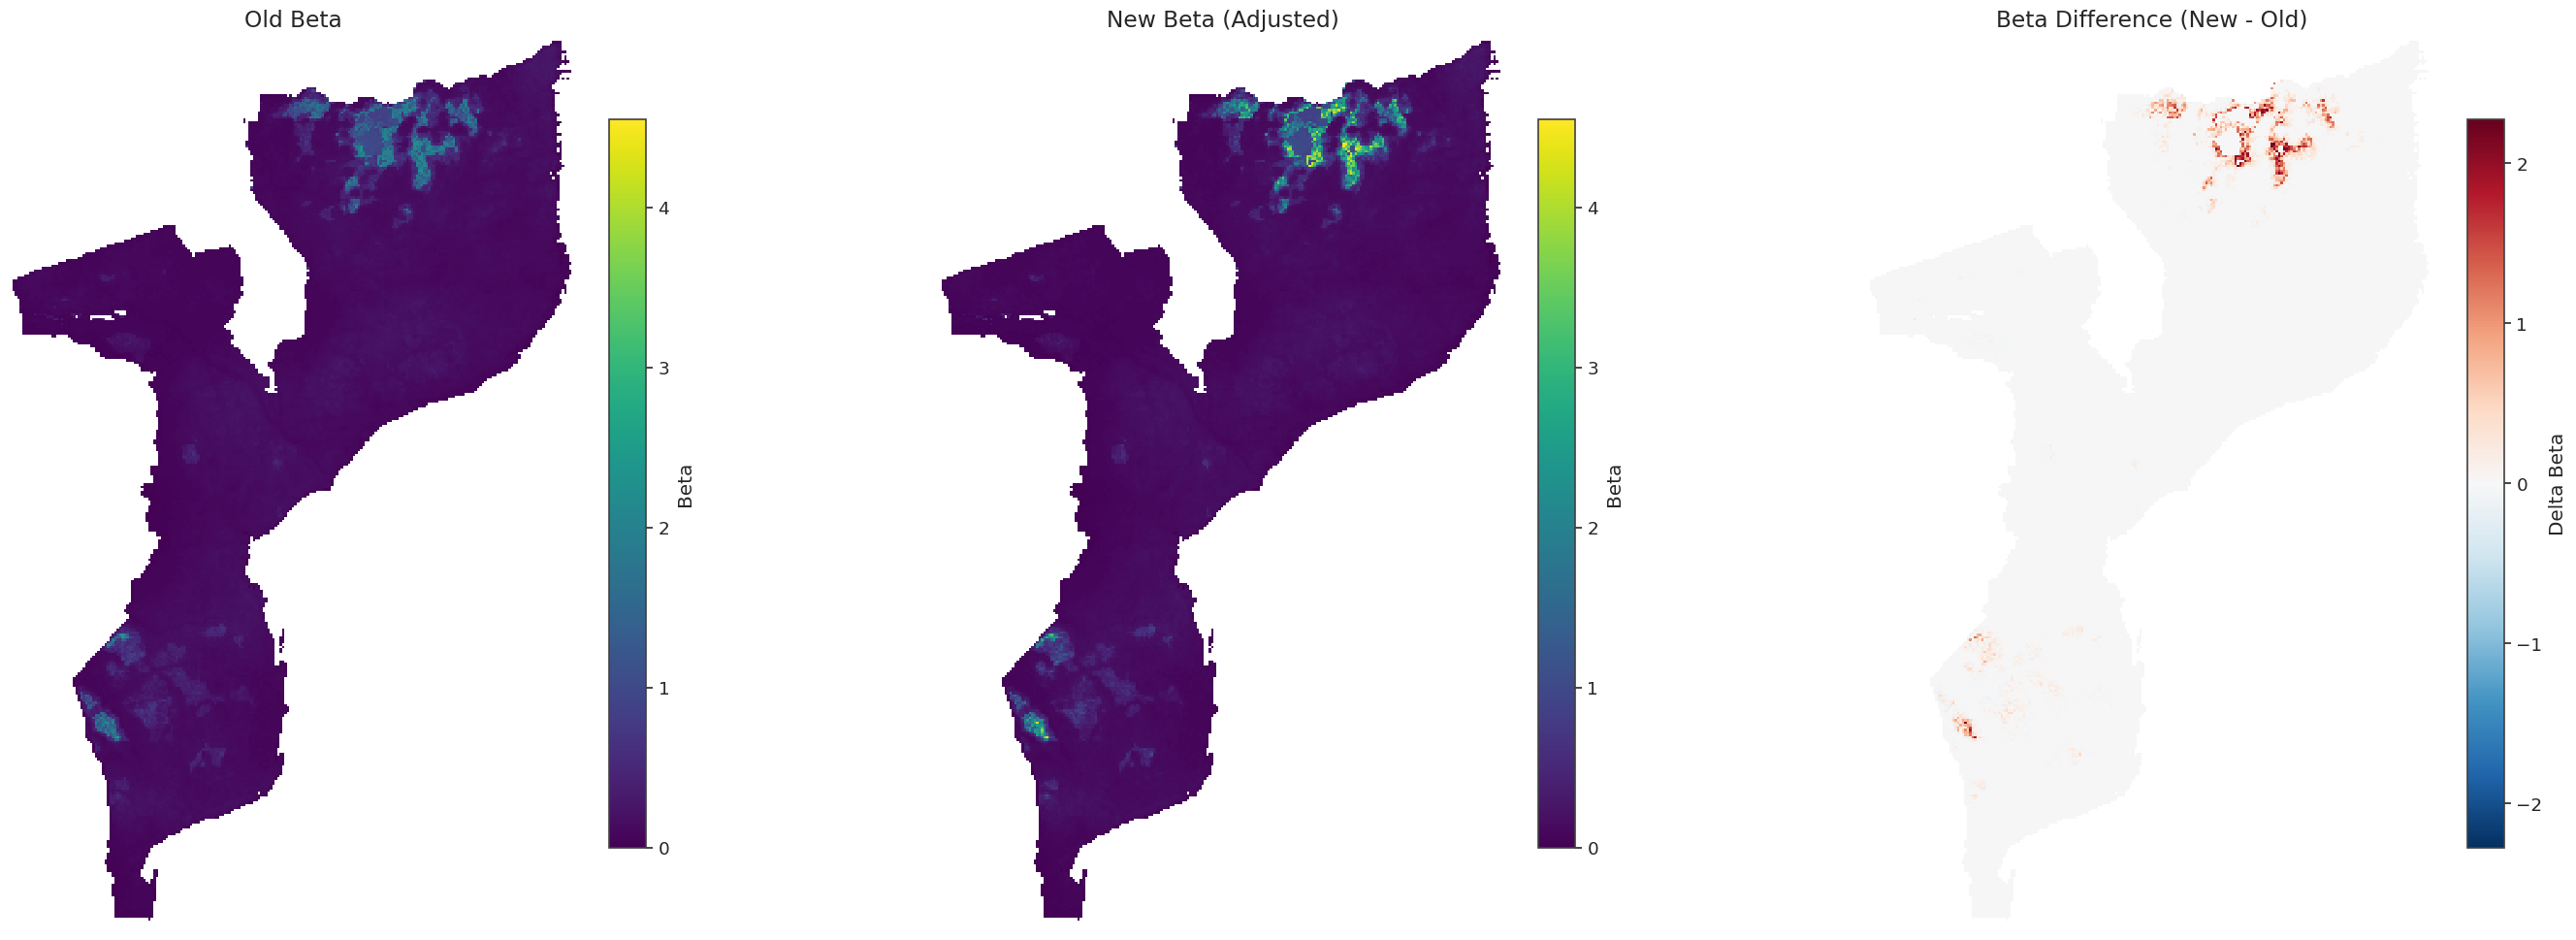

Old beta:
  min  = 0.000000
  max  = 2.509440
  mean = 0.186858

New beta:
  min  = 0.000000
  max  = 4.548680
  mean = 0.206080

Difference (new - old):
  min  = -0.438410
  max  = 2.274340
  mean = 0.019221


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import TwoSlopeNorm

ASC_PATH = f"{data_path}/moz_districts.asc"
OLD_BETA_PATH = f"{validation_input_path}/moz_beta.asc"
NEW_BETA_PATH = f"{analysis_path}/moz_beta_adjusted_using_pfpr2to10.asc"

# =============================
# Convert nodata to NaN for plotting only
# =============================
def raster_to_nan(raster: np.ndarray, nodata: float) -> np.ndarray:
    out = raster.astype(float, copy=True)
    out[out == nodata] = np.nan
    return out


# =============================
# Load data
# =============================
district_grid_raw, district_meta = read_raster(ASC_PATH)
old_beta_raw, old_meta = read_raster(OLD_BETA_PATH)
new_beta_raw, new_meta = read_raster(NEW_BETA_PATH)

district_grid = raster_to_nan(district_grid_raw, district_meta["NODATA_value"])
old_beta = raster_to_nan(old_beta_raw, old_meta["NODATA_value"])
new_beta = raster_to_nan(new_beta_raw, new_meta["NODATA_value"])

beta_diff = new_beta - old_beta

# Mask outside district if wanted
valid_district = np.isfinite(district_grid)
old_beta_plot = np.where(valid_district, old_beta, np.nan)
new_beta_plot = np.where(valid_district, new_beta, np.nan)
beta_diff_plot = np.where(valid_district, beta_diff, np.nan)

# Shared color scale for old/new beta
beta_min = np.nanmin([np.nanmin(old_beta_plot), np.nanmin(new_beta_plot)])
beta_max = np.nanmax([np.nanmax(old_beta_plot), np.nanmax(new_beta_plot)])

# Symmetric color scale for difference
diff_abs = np.nanmax(np.abs(beta_diff_plot))
diff_norm = TwoSlopeNorm(vmin=-diff_abs, vcenter=0.0, vmax=diff_abs)

# =============================
# Plot
# =============================
fig, axes = plt.subplots(1, 3, figsize=(24, 8), constrained_layout=True)

# (1) Old beta
im0 = axes[0].imshow(old_beta_plot, cmap="viridis", vmin=beta_min, vmax=beta_max)
axes[0].set_title("Old Beta", fontsize=14)
axes[0].axis("off")
cbar0 = plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
cbar0.set_label("Beta")

# (2) New beta
im1 = axes[1].imshow(new_beta_plot, cmap="viridis", vmin=beta_min, vmax=beta_max)
axes[1].set_title("New Beta (Adjusted)", fontsize=14)
axes[1].axis("off")
cbar1 = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
cbar1.set_label("Beta")

# (3) Difference
im2 = axes[2].imshow(beta_diff_plot, cmap="RdBu_r", norm=diff_norm)
axes[2].set_title("Beta Difference (New - Old)", fontsize=14)
axes[2].axis("off")
cbar2 = plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
cbar2.set_label("Delta Beta")

plt.savefig(f"{analysis_path}/beta_old_new_diff.png", dpi=200, bbox_inches="tight")
plt.show()

# =============================
# Summary stats
# =============================
print("Old beta:")
print(f"  min  = {np.nanmin(old_beta_plot):.6f}")
print(f"  max  = {np.nanmax(old_beta_plot):.6f}")
print(f"  mean = {np.nanmean(old_beta_plot):.6f}")

print("\nNew beta:")
print(f"  min  = {np.nanmin(new_beta_plot):.6f}")
print(f"  max  = {np.nanmax(new_beta_plot):.6f}")
print(f"  mean = {np.nanmean(new_beta_plot):.6f}")

print("\nDifference (new - old):")
print(f"  min  = {np.nanmin(beta_diff_plot):.6f}")
print(f"  max  = {np.nanmax(beta_diff_plot):.6f}")
print(f"  mean = {np.nanmean(beta_diff_plot):.6f}")

In [9]:
OVERRIDE_INPUT_FOLDER = True
new_validation_log_path = new_validation_path / "log"
new_validation_output_path = new_validation_path / "output"
os.makedirs(new_validation_path, exist_ok=True)
os.makedirs(new_validation_log_path, exist_ok=True)
os.makedirs(new_validation_output_path, exist_ok=True)

# Copy bin,input,script folders from old validation to new validation folder
import shutil
shutil.copytree(f"{validation_path}/bin", new_validation_path / "bin", dirs_exist_ok=True)
if OVERRIDE_INPUT_FOLDER:
    print("Overriding input folder: copying input from old validation to new validation folder.")
    shutil.copytree(f"{validation_path}/input", new_validation_path / "input", dirs_exist_ok=True)
else:
    print("Not overriding input folder: skipping copy of input from old validation to new validation folder.")
shutil.copytree(f"{validation_path}/script", new_validation_path / "script", dirs_exist_ok=True)

# Copy new beta file to new validation input folder
shutil.copy(new_beta_output_path, new_validation_path / "input" / "moz_beta.asc")

Overriding input folder: copying input from old validation to new validation folder.


PosixPath('validation_5_one_pattern_10_bin_20_rep_v42_3/input/moz_beta.asc')